# COMP4318/5318 Assignment 2: Image Classification

### Group number: ...  , SID1: ... , SID2: ..., SID3: ..., SID4: ...

*Do not include names in the submitted notebook.*

This template notebook includes code to load the  dataset and a skeleton for the main sections that should be included in the notebook. Please stick to this struture for your submitted notebook.

Please focus on making your code clear, with appropriate variable names and whitespace. Include comments and markdown text to aid the readability of your code where relevant. See the specification and marking criteria in the associated specification to guide you when completing your implementation.

## Setup and dependencies

This notebook uses `numpy`, `pandas`, `matplotlib`, `scikit-learn`, and `tensorflow/keras`.
The code below fixes random seeds to make the tuning and final evaluation more reproducible.


In [21]:
import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Hide common sklearn/keras training warnings
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
# warnings.filterwarnings("ignore", category=UserWarning)
# warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

np.seterr(divide="ignore", invalid="ignore", over="ignore")

from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.model_selection import GridSearchCV, ParameterGrid, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Make the results as reproducible as possible.
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

plt.style.use('seaborn-v0_8-whitegrid')

# Display the results in a table to improve the readability of the notebook.
def show_table(df, n=10):
    display(df.head(n).style.format(precision=4))

## 1. Data loading, exploration, and preprocessing


Code to load the dataset is provided in the first part of the following cell. The remainder of this section explores class balance, example images, and pixel intensity ranges before applying preprocessing.

,class_id,class_name
0,0,adipose
1,1,background
2,2,debris
3,3,lymphocytes
4,4,mucus
5,5,smooth muscle
6,6,normal colon mucosa
7,7,cancer-associated stroma
8,8,colorectal adenocarcinoma epithelium


--- Data Shapes ---
X_train shape: (32000, 28, 28, 3)
y_train shape: (32000,)
X_test shape:  (8000, 28, 28, 3)
y_test shape:  (8000,)
Number of classes: 9

--- Training Class Distribution ---


,train_count,train_percent
0,3490,10.91
1,3431,10.72
2,3505,10.95
3,3656,11.43
4,2950,9.22
5,4290,13.41
6,2728,8.53
7,3253,10.17
8,4697,14.68


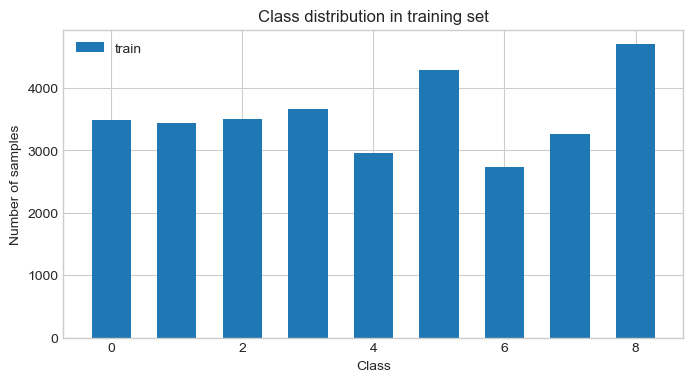

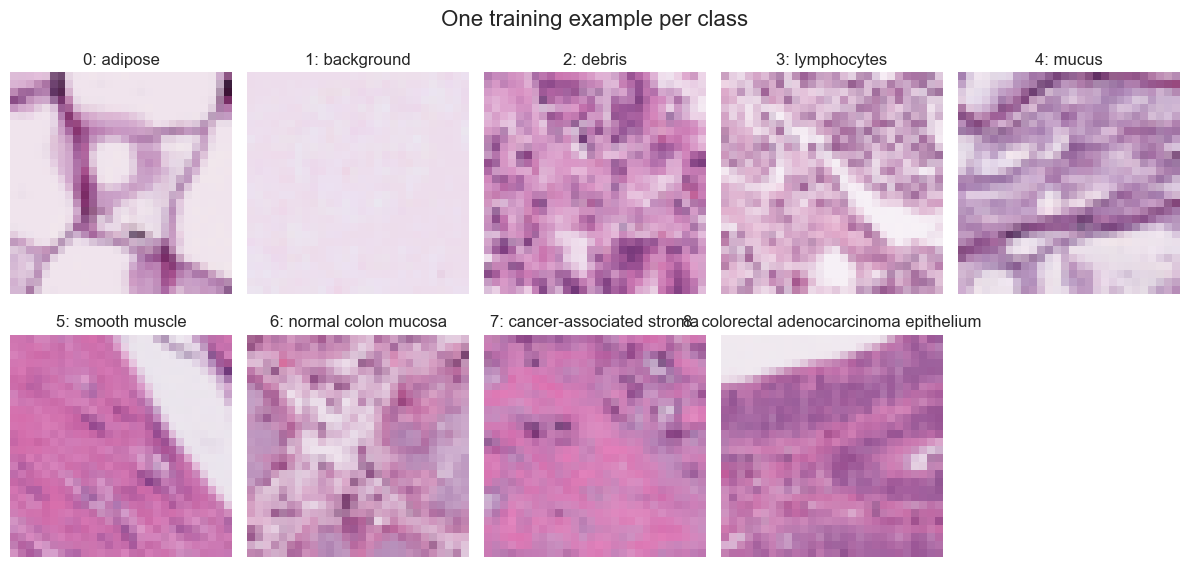

--- Pixel Intensity Summary Before Scaling ---
Min pixel value: 0
Max pixel value: 255
Mean pixel value: 168.21
Std pixel value: 43.72


,class,mean_pixel_intensity
0,0,208.67
1,1,140.97
2,2,164.57
3,3,157.37
4,4,180.28
5,5,172.24
6,6,165.66
7,7,171.08
8,8,157.46


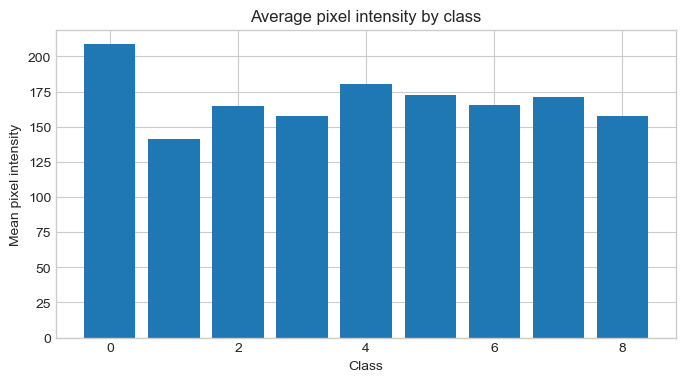

In [28]:
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

#Flatten the label into a one-dimensional label,from shape (n, 1) to (n,).
y_train_flat = y_train.ravel().astype('int64')
y_test_flat = y_test.ravel().astype('int64')

num_classes = len(np.unique(y_train_flat))

# PathMNIST class labels from the MedMNIST documentation.
class_names = {
    0: "adipose",
    1: "background",
    2: "debris",
    3: "lymphocytes",
    4: "mucus",
    5: "smooth muscle",
    6: "normal colon mucosa",
    7: "cancer-associated stroma",
    8: "colorectal adenocarcinoma epithelium"
}
assert len(class_names) == num_classes

class_names_df = pd.DataFrame({
    "class_id": list(class_names.keys()),
    "class_name": list(class_names.values())
})
display(class_names_df)

print("--- Data Shapes ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"Number of classes: {num_classes}\n")

# Determine if the training categories are severely imbalanced.
train_class_counts = pd.Series(y_train_flat).value_counts().sort_index()
class_distribution = pd.DataFrame({
    'train_count': train_class_counts,
    'train_percent': train_class_counts / len(y_train_flat) * 100
})
print("--- Training Class Distribution ---")
display(class_distribution.style.format({'train_percent': '{:.2f}'}))

plt.figure(figsize=(8, 4))
plt.bar(class_distribution.index, class_distribution['train_count'], width=0.6, label='train')
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Class distribution in training set')
plt.legend()
plt.show()

# One image is displayed for each category, and the similarity of the images in terms of color, structure, and category is observed.
plt.figure(figsize=(12, 6))
for cls in range(num_classes):
    plt.subplot(2, int(np.ceil(num_classes / 2)), cls + 1)
    image_index = np.where(y_train_flat == cls)[0][0]
    plt.imshow(X_train[image_index])
    plt.title(f"{cls}: {class_names.get(cls, 'unknown')}")
    plt.axis('off')
plt.suptitle("One training example per class", fontsize=16)
plt.tight_layout()
plt.show()

# Pixel intensity statistics serve as a basis for normalization. 
# Average pixel intensity for each category is used to determine if the brightness distribution differs across categories.
print("--- Pixel Intensity Summary Before Scaling ---")
print(f"Min pixel value: {X_train.min()}")
print(f"Max pixel value: {X_train.max()}")
print(f"Mean pixel value: {X_train.mean():.2f}")
print(f"Std pixel value: {X_train.std():.2f}")

mean_intensity_by_class = []
for cls in range(num_classes):
    class_images = X_train[y_train_flat == cls]
    mean_intensity_by_class.append(class_images.mean())

mean_intensity_df = pd.DataFrame({
    'class': range(num_classes),
    'mean_pixel_intensity': mean_intensity_by_class
})
display(mean_intensity_df.style.format({'mean_pixel_intensity': '{:.2f}'}))

plt.figure(figsize=(8, 4))
plt.bar(mean_intensity_df['class'], mean_intensity_df['mean_pixel_intensity'])
plt.xlabel('Class')
plt.ylabel('Mean pixel intensity')
plt.title('Average pixel intensity by class')
plt.show()

# Scaling the pixels from [0, 255] to [0, 1] can make gradient updates more stable.
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# The image is flattened into a 2352-dimensional vector for use by SVM and MLP.
# CNN retains the (28, 28, 3) spatial structure.
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

# Stratified validation split for neural-network tuning.
X_nn_train, X_val, y_nn_train, y_val = train_test_split(
    X_train_norm,
    y_train_flat,
    test_size=0.20,
    stratify=y_train_flat,
    random_state=SEED
)

X_nn_train_flat = X_nn_train.reshape(X_nn_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

### Examples of preprocessed data

The following cell checks that preprocessing produced the expected shapes and pixel range. It also displays examples after scaling, so the marker can see that the images remain visually meaningful.

--- Pre-processed Data Shapes ---
CNN train input (X_train_norm): (32000, 28, 28, 3)
SVM/MLP train input (X_train_flat): (32000, 2352)
Validation CNN input (X_val): (6400, 28, 28, 3)
Validation flat input (X_val_flat): (6400, 2352)
Target vector (y_train_flat): (32000,)

--- Pixel Range After Scaling ---
X_train_norm min: 0.000
X_train_norm max: 1.000
X_train_norm mean: 0.660
X_train_norm std: 0.171


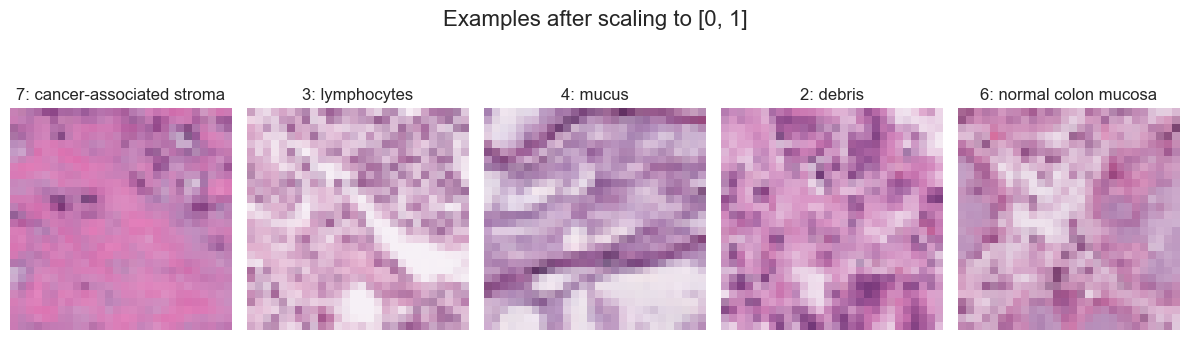


--- Validation Split Class Proportions ---


,validation_proportion
0,0.109
1,0.107
2,0.110
3,0.114
4,0.092
5,0.134
6,0.085
7,0.102
8,0.147


In [23]:
print("--- Pre-processed Data Shapes ---")
print(f"CNN train input (X_train_norm): {X_train_norm.shape}")
print(f"SVM/MLP train input (X_train_flat): {X_train_flat.shape}")
print(f"Validation CNN input (X_val): {X_val.shape}")
print(f"Validation flat input (X_val_flat): {X_val_flat.shape}")
print(f"Target vector (y_train_flat): {y_train_flat.shape}")

print("\n--- Pixel Range After Scaling ---")
print(f"X_train_norm min: {X_train_norm.min():.3f}")
print(f"X_train_norm max: {X_train_norm.max():.3f}")
print(f"X_train_norm mean: {X_train_norm.mean():.3f}")
print(f"X_train_norm std: {X_train_norm.std():.3f}")

plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train_norm[i])
    label = int(y_train_flat[i])
    plt.title(f"{label}: {class_names.get(label, 'unknown')}")
    plt.axis('off')
plt.suptitle("Examples after scaling to [0, 1]", fontsize=16)
plt.tight_layout()
plt.show()

validation_distribution = pd.Series(y_val).value_counts(normalize=True).sort_index()
print("\n--- Validation Split Class Proportions ---")
display(validation_distribution.to_frame('validation_proportion').style.format('{:.3f}'))

## 2. Algorithm design and setup

### Algorithm of choice from first six weeks of course

I use an RBF-kernel Support Vector Machine (SVM). It is suitable here because it was covered in the first six weeks and can handle non-linear decision boundaries in the flattened image feature space. PCA is included in the tuning pipeline to reduce the raw 2,352 pixel features before the SVM is fitted.

In [24]:
base_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=100, random_state=SEED)),
    ('svm', SVC(kernel='rbf', random_state=SEED))
])

print("Base PCA + RBF-SVM model initialized.")

Base PCA + RBF-SVM model initialized.


### Fully connected neural network

The MLP receives flattened images. Dropout is included as regularisation to reduce overfitting, and the number of hidden layers/units is kept small so tuning remains practical.

In [25]:
def build_mlp(hidden_units=64, hidden_layers=1, dropout=0.20, learning_rate=0.001):

    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_flat.shape[1],)))

    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_units, activation='relu'))
        if dropout > 0:
            model.add(layers.Dropout(dropout))

    model.add(layers.Dense(num_classes, activation='softmax'))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

test_mlp = build_mlp()
test_mlp.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │       150,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,177 (590.54 KB)

 Trainable params: 151,177 (590.54 KB)

 Non-trainable params: 0 (0.00 B)

### Convolutional neural network

The CNN keeps the spatial image layout. The convolution and pooling layers learn local image patterns, while the dense layer combines these features for classification.

In [26]:
def build_cnn(filters=32, kernel_size=3, dense_units=64, dropout=0.25, learning_rate=0.001):

    model = keras.Sequential()
    model.add(layers.Input(shape=(28, 28, 3)))

    model.add(layers.Conv2D(filters, kernel_size=(kernel_size, kernel_size), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Conv2D(filters * 2, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation='relu'))

    if dropout > 0:
        model.add(layers.Dropout(dropout))

    model.add(layers.Dense(num_classes, activation='softmax'))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

test_cnn = build_cnn()
test_cnn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,745 (862.29 KB)

 Trainable params: 220,745 (862.29 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Hyperparameter tuning

The test set is not used in this section. The SVM uses stratified cross-validation on a stratified subset to keep runtime reasonable. The neural networks use the validation set created above, with early stopping to reduce unnecessary epochs. Each tuning cell records accuracy and runtime so the report can discuss both performance and cost.

### Algorithm of choice from first six weeks of course

Tuning SVM on a stratified subset of 6400 samples to save time...

Grid Search completed in 547.06 seconds.
Best Hyperparameters: {'pca__n_components': 50, 'svm__C': 10, 'svm__gamma': 'scale'}
Best Cross-Validation Accuracy: 0.6287


,param_pca__n_components,param_svm__C,param_svm__gamma,mean_train_score,mean_test_score,std_test_score,mean_fit_time,total_fit_time,rank_test_score
2,50,10,scale,0.8614,0.6287,0.0007,9.0803,27.2409,1
0,50,1,scale,0.6996,0.6150,0.0057,7.6510,22.9531,2
8,100,10,scale,0.9134,0.6108,0.0079,4.5743,13.7228,3
4,50,30,scale,0.9228,0.6092,0.0042,5.0679,15.2037,4
6,100,1,scale,0.7263,0.6063,0.0013,4.5943,13.7829,5
12,150,1,scale,0.7410,0.6006,0.0017,4.8857,14.6570,6
14,150,10,scale,0.9370,0.5961,0.0075,4.8046,14.4138,7
10,100,30,scale,0.9609,0.5902,0.0086,4.6859,14.0576,8
16,150,30,scale,0.9792,0.5758,0.0062,4.9463,14.8390,9
5,50,30,0.0100,1.0000,0.4784,0.0046,5.7476,17.2427,10


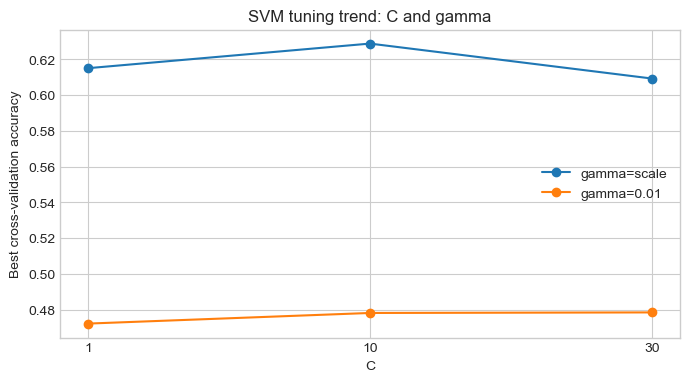

In [27]:
X_tune, _, y_tune, _ = train_test_split(
    X_train_flat, 
    y_train_flat, 
    train_size=0.20,
    stratify=y_train_flat, 
    random_state=SEED
)

print(f"Tuning SVM on a stratified subset of {X_tune.shape[0]} samples to save time...")

candidate_pca_components = [50, 100, 150]
candidate_pca_components = [n for n in candidate_pca_components if n < min(X_tune.shape[0], X_tune.shape[1])]

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(svd_solver='full')),
    ('svm', SVC(kernel='rbf', random_state=SEED))
])

param_grid = {
    'pca__n_components': candidate_pca_components,
    'svm__C': [1, 10, 30],
    'svm__gamma': ['scale', 0.01]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=1,
    verbose=0,
    return_train_score=True
)

start_time = time.time()

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    warnings.filterwarnings("ignore", message=".*matmul.*", category=RuntimeWarning)
    grid_search.fit(X_tune, y_tune)

svm_tuning_time = time.time() - start_time

print(f"\nGrid Search completed in {svm_tuning_time:.2f} seconds.")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

svm_results_df = pd.DataFrame(grid_search.cv_results_)
svm_results_df['total_fit_time'] = svm_results_df['mean_fit_time'] * cv.get_n_splits()
svm_results_table = svm_results_df[
    [
        'param_pca__n_components',
        'param_svm__C',
        'param_svm__gamma',
        'mean_train_score',
        'mean_test_score',
        'std_test_score',
        'mean_fit_time',
        'total_fit_time',
        'rank_test_score'
    ]
].sort_values('rank_test_score')

show_table(svm_results_table, n=10)

best_svm_params = grid_search.best_params_.copy()

plt.figure(figsize=(8, 4))
for gamma_value in svm_results_table['param_svm__gamma'].unique():
    subset = svm_results_table[svm_results_table['param_svm__gamma'] == gamma_value]
    grouped = subset.groupby('param_svm__C')['mean_test_score'].max()
    plt.plot(grouped.index.astype(str), grouped.values, marker='o', label=f'gamma={gamma_value}')
plt.xlabel('C')
plt.ylabel('Best cross-validation accuracy')
plt.title('SVM tuning trend: C and gamma')
plt.legend()
plt.show()

### Fully connected neural network

Starting MLP hyperparameter search over 16 combinations...
MLP trial 1/16: {'batch_size': 64, 'dropout': 0.0, 'epochs': 20, 'hidden_layers': 1, 'hidden_units': 64, 'learning_rate': 0.001}

MLP trial 2/16: {'batch_size': 64, 'dropout': 0.0, 'epochs': 20, 'hidden_layers': 1, 'hidden_units': 64, 'learning_rate': 0.0001}
MLP trial 3/16: {'batch_size': 64, 'dropout': 0.0, 'epochs': 20, 'hidden_layers': 1, 'hidden_units': 128, 'learning_rate': 0.001}
MLP trial 4/16: {'batch_size': 64, 'dropout': 0.0, 'epochs': 20, 'hidden_layers': 1, 'hidden_units': 128, 'learning_rate': 0.0001}
MLP trial 5/16: {'batch_size': 64, 'dropout': 0.0, 'epochs': 20, 'hidden_layers': 2, 'hidden_units': 64, 'learning_rate': 0.001}
MLP trial 6/16: {'batch_size': 64, 'dropout': 0.0, 'epochs': 20, 'hidden_layers': 2, 'hidden_units': 64, 'learning_rate': 0.0001}
MLP trial 7/16: {'batch_size': 64, 'dropout': 0.0, 'epochs': 20, 'hidden_layers': 2, 'hidden_units': 128, 'learning_rate': 0.001}
MLP trial 8/16: {'batch_size': 

,trial,batch_size,dropout,epochs,hidden_layers,hidden_units,learning_rate,best_epoch,best_val_accuracy,runtime_seconds
6,7,64,0.0000,20,2,128,0.0010,20,0.5403,32.7505
4,5,64,0.0000,20,2,64,0.0010,12,0.5233,18.0699
7,8,64,0.0000,20,2,128,0.0001,20,0.5103,32.9414
15,16,64,0.3000,20,2,128,0.0001,19,0.4884,32.6397
5,6,64,0.0000,20,2,64,0.0001,20,0.4762,23.6593
0,1,64,0.0000,20,1,64,0.0010,15,0.4695,18.5638
3,4,64,0.0000,20,1,128,0.0001,19,0.4616,31.4963
13,14,64,0.3000,20,2,64,0.0001,20,0.4483,22.2188
1,2,64,0.0000,20,1,64,0.0001,20,0.4367,22.1272
11,12,64,0.3000,20,1,128,0.0001,13,0.4305,24.0997


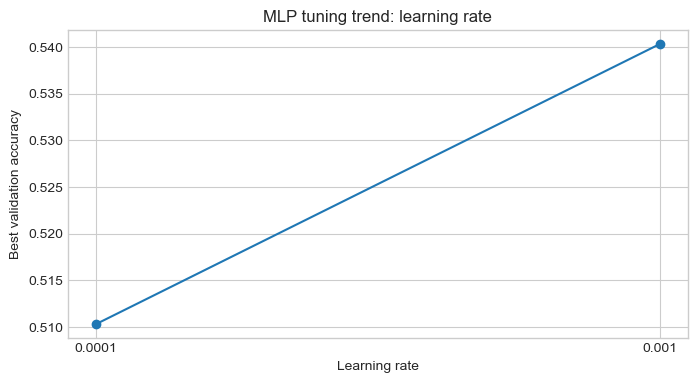

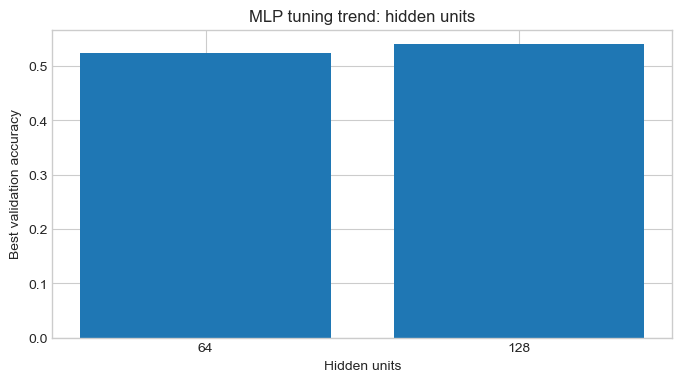

In [10]:
def tune_mlp_model(params, trial_number):
    keras.backend.clear_session()

    model = build_mlp(
        hidden_units=params['hidden_units'],
        hidden_layers=params['hidden_layers'],
        dropout=params['dropout'],
        learning_rate=params['learning_rate']
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    )

    start_time = time.time()
    history = model.fit(
        X_nn_train_flat,
        y_nn_train,
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        validation_data=(X_val_flat, y_val),
        callbacks=[early_stop],
        verbose=0
    )
    runtime = time.time() - start_time

    best_epoch = int(np.argmax(history.history['val_accuracy']) + 1)
    best_val_accuracy = float(np.max(history.history['val_accuracy']))

    return {
        'trial': trial_number,
        **params,
        'best_epoch': best_epoch,
        'best_val_accuracy': best_val_accuracy,
        'runtime_seconds': runtime
    }

mlp_param_grid = list(ParameterGrid({
    'hidden_units': [64, 128],
    'hidden_layers': [1, 2],
    'dropout': [0.0, 0.30],
    'learning_rate': [1e-3, 1e-4],
    'batch_size': [64],
    'epochs': [20]
}))

print(f"Starting MLP hyperparameter search over {len(mlp_param_grid)} combinations...")

mlp_results = []
mlp_start_time = time.time()

for trial_number, params in enumerate(mlp_param_grid, start=1):
    print(f"MLP trial {trial_number}/{len(mlp_param_grid)}: {params}")
    mlp_results.append(tune_mlp_model(params, trial_number))

mlp_tuning_time = time.time() - mlp_start_time
mlp_results_df = pd.DataFrame(mlp_results).sort_values('best_val_accuracy', ascending=False)

best_mlp_params = mlp_results_df.iloc[0][
    ['hidden_units', 'hidden_layers', 'dropout', 'learning_rate', 'batch_size', 'epochs', 'best_epoch']
].to_dict()

best_mlp_params['hidden_units'] = int(best_mlp_params['hidden_units'])
best_mlp_params['hidden_layers'] = int(best_mlp_params['hidden_layers'])
best_mlp_params['batch_size'] = int(best_mlp_params['batch_size'])
best_mlp_params['epochs'] = int(best_mlp_params['epochs'])
best_mlp_params['best_epoch'] = int(best_mlp_params['best_epoch'])

print(f"\nMLP tuning completed in {mlp_tuning_time:.2f} seconds.")
print(f"Best MLP hyperparameters: {best_mlp_params}")
print(f"Best MLP validation accuracy: {mlp_results_df.iloc[0]['best_val_accuracy']:.4f}")

show_table(mlp_results_df, n=10)

plt.figure(figsize=(8, 4))
mlp_learning_rate_trend = mlp_results_df.groupby('learning_rate')['best_val_accuracy'].max()
plt.plot(mlp_learning_rate_trend.index.astype(str), mlp_learning_rate_trend.values, marker='o')
plt.xlabel('Learning rate')
plt.ylabel('Best validation accuracy')
plt.title('MLP tuning trend: learning rate')
plt.show()

plt.figure(figsize=(8, 4))
mlp_units_trend = mlp_results_df.groupby('hidden_units')['best_val_accuracy'].max()
plt.bar(mlp_units_trend.index.astype(str), mlp_units_trend.values)
plt.xlabel('Hidden units')
plt.ylabel('Best validation accuracy')
plt.title('MLP tuning trend: hidden units')
plt.show()

### Convolutional neural network

Starting CNN hyperparameter search over 12 sampled combinations...
CNN trial 1/12: {'batch_size': 64, 'dense_units': 64, 'dropout': 0.4, 'epochs': 20, 'filters': 16, 'kernel_size': 5, 'learning_rate': 0.001}
CNN trial 2/12: {'batch_size': 64, 'dense_units': 64, 'dropout': 0.25, 'epochs': 20, 'filters': 16, 'kernel_size': 5, 'learning_rate': 0.001}
CNN trial 3/12: {'batch_size': 64, 'dense_units': 128, 'dropout': 0.25, 'epochs': 20, 'filters': 16, 'kernel_size': 3, 'learning_rate': 0.0001}
CNN trial 4/12: {'batch_size': 64, 'dense_units': 128, 'dropout': 0.25, 'epochs': 20, 'filters': 16, 'kernel_size': 3, 'learning_rate': 0.001}
CNN trial 5/12: {'batch_size': 64, 'dense_units': 64, 'dropout': 0.4, 'epochs': 20, 'filters': 32, 'kernel_size': 5, 'learning_rate': 0.0001}
CNN trial 6/12: {'batch_size': 64, 'dense_units': 128, 'dropout': 0.25, 'epochs': 20, 'filters': 32, 'kernel_size': 5, 'learning_rate': 0.001}
CNN trial 7/12: {'batch_size': 64, 'dense_units': 64, 'dropout': 0.25, 'epochs

,trial,batch_size,dense_units,dropout,epochs,filters,kernel_size,learning_rate,best_epoch,best_val_accuracy,runtime_seconds
3,4,64,128,0.2500,20,16,3,0.0010,16,0.7937,74.9229
8,9,64,128,0.4000,20,32,3,0.0001,20,0.7597,173.5402
1,2,64,64,0.2500,20,16,5,0.0010,12,0.7552,52.2943
7,8,64,128,0.4000,20,16,3,0.0010,9,0.7541,51.6601
10,11,64,128,0.4000,20,32,5,0.0001,20,0.7412,185.1750
11,12,64,64,0.2500,20,32,3,0.0001,20,0.7319,145.5431
2,3,64,128,0.2500,20,16,3,0.0001,20,0.7270,74.4211
9,10,64,128,0.2500,20,16,5,0.0001,19,0.7186,83.2085
5,6,64,128,0.2500,20,32,5,0.0010,3,0.7048,61.6915
4,5,64,64,0.4000,20,32,5,0.0001,17,0.7000,186.5898


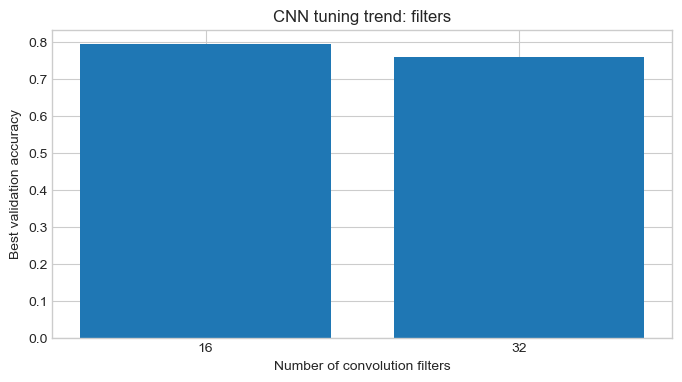

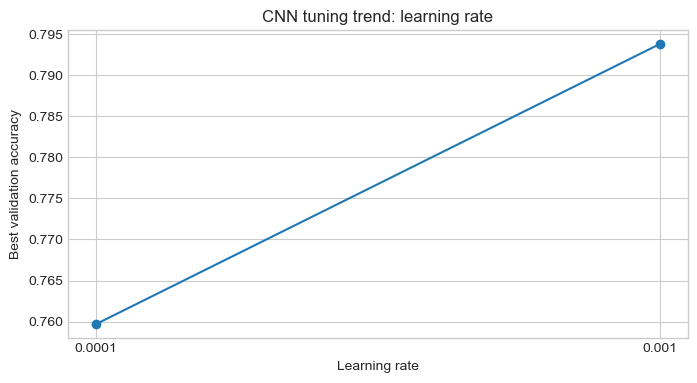

In [11]:
def tune_cnn_model(params, trial_number):
    keras.backend.clear_session()

    model = build_cnn(
        filters=params['filters'],
        kernel_size=params['kernel_size'],
        dense_units=params['dense_units'],
        dropout=params['dropout'],
        learning_rate=params['learning_rate']
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    )

    start_time = time.time()
    history = model.fit(
        X_nn_train,
        y_nn_train,
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=0
    )
    runtime = time.time() - start_time

    best_epoch = int(np.argmax(history.history['val_accuracy']) + 1)
    best_val_accuracy = float(np.max(history.history['val_accuracy']))

    return {
        'trial': trial_number,
        **params,
        'best_epoch': best_epoch,
        'best_val_accuracy': best_val_accuracy,
        'runtime_seconds': runtime
    }
# A complete grid is too time-consuming, so a random search with a fixed random seed is used to cover multiple key hyperparameters under a controllable runtime.
cnn_param_grid = list(ParameterGrid({
    'filters': [16, 32],
    'kernel_size': [3, 5],
    'dense_units': [64, 128],
    'dropout': [0.25, 0.40],
    'learning_rate': [1e-3, 1e-4],
    'batch_size': [64],
    'epochs': [20]
}))

# Randomly sample the CNN grid to keep runtime reasonable while still searching over 5 hyperparameters.
rng = np.random.default_rng(SEED)
max_cnn_trials = min(12, len(cnn_param_grid))
sampled_indices = rng.choice(len(cnn_param_grid), size=max_cnn_trials, replace=False)
cnn_param_grid = [cnn_param_grid[i] for i in sampled_indices]

print(f"Starting CNN hyperparameter search over {len(cnn_param_grid)} sampled combinations...")

cnn_results = []
cnn_start_time = time.time()

for trial_number, params in enumerate(cnn_param_grid, start=1):
    print(f"CNN trial {trial_number}/{len(cnn_param_grid)}: {params}")
    cnn_results.append(tune_cnn_model(params, trial_number))

cnn_tuning_time = time.time() - cnn_start_time
cnn_results_df = pd.DataFrame(cnn_results).sort_values('best_val_accuracy', ascending=False)

best_cnn_params = cnn_results_df.iloc[0][
    ['filters', 'kernel_size', 'dense_units', 'dropout', 'learning_rate', 'batch_size', 'epochs', 'best_epoch']
].to_dict()

best_cnn_params['filters'] = int(best_cnn_params['filters'])
best_cnn_params['kernel_size'] = int(best_cnn_params['kernel_size'])
best_cnn_params['dense_units'] = int(best_cnn_params['dense_units'])
best_cnn_params['batch_size'] = int(best_cnn_params['batch_size'])
best_cnn_params['epochs'] = int(best_cnn_params['epochs'])
best_cnn_params['best_epoch'] = int(best_cnn_params['best_epoch'])

print(f"\nCNN tuning completed in {cnn_tuning_time:.2f} seconds.")
print(f"Best CNN hyperparameters: {best_cnn_params}")
print(f"Best CNN validation accuracy: {cnn_results_df.iloc[0]['best_val_accuracy']:.4f}")

show_table(cnn_results_df, n=10)

plt.figure(figsize=(8, 4))
cnn_filter_trend = cnn_results_df.groupby('filters')['best_val_accuracy'].max()
plt.bar(cnn_filter_trend.index.astype(str), cnn_filter_trend.values)
plt.xlabel('Number of convolution filters')
plt.ylabel('Best validation accuracy')
plt.title('CNN tuning trend: filters')
plt.show()

plt.figure(figsize=(8, 4))
cnn_lr_trend = cnn_results_df.groupby('learning_rate')['best_val_accuracy'].max()
plt.plot(cnn_lr_trend.index.astype(str), cnn_lr_trend.values, marker='o')
plt.xlabel('Learning rate')
plt.ylabel('Best validation accuracy')
plt.title('CNN tuning trend: learning rate')
plt.show()

## 4. Final models

The following cells can run even if the hyperparameter tuning cells above are skipped. If the tuning cells have been run, the best parameters found above are used automatically. Otherwise, the fallback parameters below allow the final model cells to run independently; after running your own search, update the fallback values to match the printed best parameters before submitting.

### Algorithm of choice from first six weeks of course

In [12]:
selected_svm_params = globals().get('best_svm_params', {
    'pca__n_components': 50,
    'svm__C': 10,
    'svm__gamma': 'scale'
})

selected_svm_params['pca__n_components'] = min(
    int(selected_svm_params['pca__n_components']),
    X_train_flat.shape[0] - 1,
    X_train_flat.shape[1]
)

final_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=selected_svm_params['pca__n_components'], random_state=SEED)),
    ('svm', SVC(
        kernel='rbf',
        C=selected_svm_params['svm__C'],
        gamma=selected_svm_params['svm__gamma'],
        random_state=SEED
    ))
])

print("Training final SVM on the full training dataset...")
start_time = time.time()
final_svm.fit(X_train_flat, y_train_flat)
svm_train_time = time.time() - start_time

start_time = time.time()
y_pred_svm = final_svm.predict(X_test_flat)
svm_predict_time = time.time() - start_time

svm_test_accuracy = accuracy_score(y_test_flat, y_pred_svm)

print(f"Selected SVM Hyperparameters: {selected_svm_params}")
print(f"Final SVM Training Time: {svm_train_time:.2f} seconds")
print(f"Final SVM Prediction Time: {svm_predict_time:.2f} seconds")
print(f"Final SVM Test Accuracy: {svm_test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred_svm, zero_division=0))

Training final SVM on the full training dataset...
Selected SVM Hyperparameters: {'pca__n_components': 50, 'svm__C': 10, 'svm__gamma': 'scale'}
Final SVM Training Time: 45.97 seconds
Final SVM Prediction Time: 22.92 seconds
Final SVM Test Accuracy: 0.6820

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       873
           1       0.94      0.89      0.91       858
           2       0.47      0.36      0.41       877
           3       0.92      0.92      0.92       914
           4       0.64      0.62      0.63       737
           5       0.68      0.66      0.67      1072
           6       0.51      0.42      0.46       682
           7       0.50      0.57      0.53       813
           8       0.58      0.66      0.62      1174

    accuracy                           0.68      8000
   macro avg       0.68      0.67      0.67      8000
weighted avg       0.68      0.68      0.68      8000



### Fully connected neural network

In [13]:
# Fallback values keep this cell independent of the MLP tuning cell.
selected_mlp_params = globals().get('best_mlp_params', {
    'hidden_units': 64,
    'hidden_layers': 2,
    'dropout': 0.00,
    'learning_rate': 0.001,
    'batch_size': 64,
    'epochs': 20,
    'best_epoch': 20
})

print("Training final MLP model...")
print(f"Selected MLP Hyperparameters: {selected_mlp_params}")

keras.backend.clear_session()
final_mlp = build_mlp(
    hidden_units=int(selected_mlp_params['hidden_units']),
    hidden_layers=int(selected_mlp_params['hidden_layers']),
    dropout=float(selected_mlp_params['dropout']),
    learning_rate=float(selected_mlp_params['learning_rate'])
)

final_mlp_epochs = int(selected_mlp_params.get('best_epoch', selected_mlp_params['epochs']))

start_time = time.time()
history_mlp = final_mlp.fit(
    X_train_flat,
    y_train_flat,
    epochs=final_mlp_epochs,
    batch_size=int(selected_mlp_params['batch_size']),
    verbose=0
)
mlp_train_time = time.time() - start_time

start_time = time.time()
mlp_predictions = np.argmax(final_mlp.predict(X_test_flat, verbose=0), axis=-1)
mlp_predict_time = time.time() - start_time

mlp_test_acc = accuracy_score(y_test_flat, mlp_predictions)

print(f"Final MLP Training Time: {mlp_train_time:.2f} seconds")
print(f"Final MLP Prediction Time: {mlp_predict_time:.2f} seconds")
print(f"Final MLP Test Accuracy: {mlp_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_flat, mlp_predictions, zero_division=0))

Training final MLP model...
Selected MLP Hyperparameters: {'hidden_units': 128, 'hidden_layers': 2, 'dropout': 0.0, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 20, 'best_epoch': 20}
Final MLP Training Time: 36.19 seconds
Final MLP Prediction Time: 0.54 seconds
Final MLP Test Accuracy: 0.5784

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.91      0.84       873
           1       0.89      0.76      0.82       858
           2       0.39      0.46      0.42       877
           3       0.62      0.77      0.68       914
           4       0.54      0.62      0.58       737
           5       0.57      0.54      0.55      1072
           6       0.32      0.14      0.20       682
           7       0.42      0.32      0.36       813
           8       0.53      0.58      0.55      1174

    accuracy                           0.58      8000
   macro avg       0.56      0.57      0.56      8000
weighted avg       0.57  

### Convolutional neural network

In [14]:
# Fallback values keep this cell independent of the CNN tuning cell.
selected_cnn_params = globals().get('best_cnn_params', {
    'filters': 16,
    'kernel_size': 3,
    'dense_units': 128,
    'dropout': 0.25,
    'learning_rate': 0.001,
    'batch_size': 64,
    'epochs': 20,
    'best_epoch': 20
})

print("Training final CNN model...")
print(f"Selected CNN Hyperparameters: {selected_cnn_params}")

keras.backend.clear_session()
final_cnn = build_cnn(
    filters=int(selected_cnn_params['filters']),
    kernel_size=int(selected_cnn_params['kernel_size']),
    dense_units=int(selected_cnn_params['dense_units']),
    dropout=float(selected_cnn_params['dropout']),
    learning_rate=float(selected_cnn_params['learning_rate'])
)

final_cnn_epochs = int(selected_cnn_params.get('best_epoch', selected_cnn_params['epochs']))

start_time = time.time()
history_cnn = final_cnn.fit(
    X_train_norm,
    y_train_flat,
    epochs=final_cnn_epochs,
    batch_size=int(selected_cnn_params['batch_size']),
    verbose=0
)
cnn_train_time = time.time() - start_time

start_time = time.time()
cnn_predictions = np.argmax(final_cnn.predict(X_test_norm, verbose=0), axis=-1)
cnn_predict_time = time.time() - start_time

cnn_test_acc = accuracy_score(y_test_flat, cnn_predictions)

print(f"Final CNN Training Time: {cnn_train_time:.2f} seconds")
print(f"Final CNN Prediction Time: {cnn_predict_time:.2f} seconds")
print(f"Final CNN Test Accuracy: {cnn_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_flat, cnn_predictions, zero_division=0))

Training final CNN model...
Selected CNN Hyperparameters: {'filters': 16, 'kernel_size': 3, 'dense_units': 128, 'dropout': 0.25, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 20, 'best_epoch': 16}
Final CNN Training Time: 72.59 seconds
Final CNN Prediction Time: 0.82 seconds
Final CNN Test Accuracy: 0.7911

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       873
           1       0.97      0.96      0.96       858
           2       0.71      0.62      0.66       877
           3       0.91      0.97      0.94       914
           4       0.71      0.77      0.74       737
           5       0.78      0.76      0.77      1072
           6       0.66      0.65      0.65       682
           7       0.65      0.46      0.54       813
           8       0.77      0.87      0.82      1174

    accuracy                           0.79      8000
   macro avg       0.78      0.78      0.78      8000
weighted avg

### Final model comparison and confusion matrices

This cell creates a clean results table and confusion matrices for the report. It goes beyond accuracy by including macro precision/recall/F1, which is useful when classes are not perfectly balanced.

,model,selected_hyperparameters,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_seconds,prediction_time_seconds
0,PCA + RBF-SVM,"{'pca__n_components': 50, 'svm__C': 10, 'svm__gamma': 'scale'}",0.6819,0.6758,0.6743,0.6729,0.6781,13.08,10.89
1,MLP,"{'hidden_units': 64, 'hidden_layers': 2, 'dropout': 0.0, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 20}",0.5411,0.5088,0.5242,0.4979,0.5104,9.35,0.11
2,CNN,"{'filters': 16, 'kernel_size': 3, 'dense_units': 128, 'dropout': 0.25, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 20}",0.7965,0.7926,0.7917,0.7887,0.7942,46.62,0.31


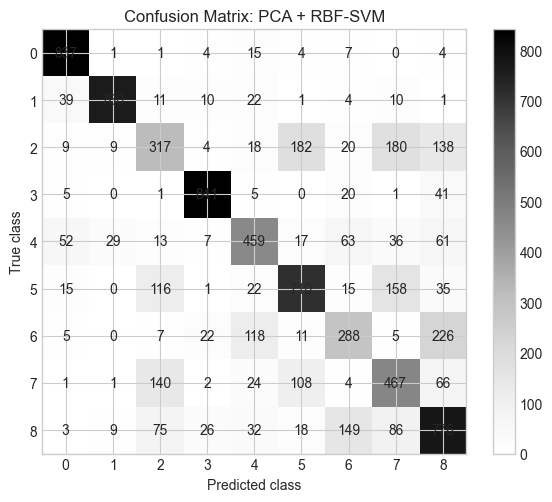

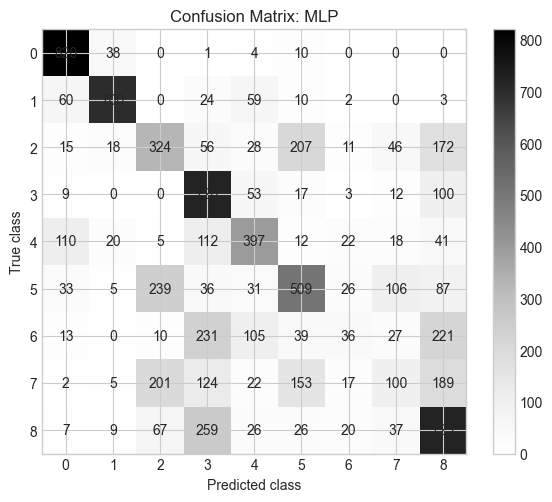

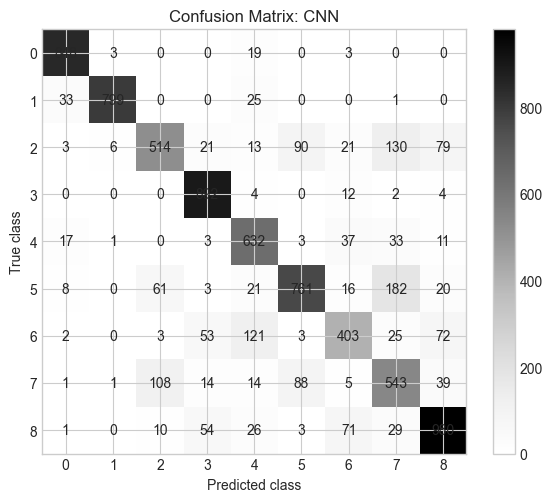

In [61]:
def make_result_row(model_name, params, y_pred, train_time, predict_time):
    return {
        'model': model_name,
        'selected_hyperparameters': params,
        'test_accuracy': accuracy_score(y_test_flat, y_pred),
        'macro_precision': precision_score(y_test_flat, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_test_flat, y_pred, average='macro', zero_division=0),
        'macro_f1': f1_score(y_test_flat, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_test_flat, y_pred, average='weighted', zero_division=0),
        'training_time_seconds': train_time,
        'prediction_time_seconds': predict_time
    }

final_results = [
    make_result_row('PCA + RBF-SVM', selected_svm_params, y_pred_svm, svm_train_time, svm_predict_time),
    make_result_row('MLP', selected_mlp_params, mlp_predictions, mlp_train_time, mlp_predict_time),
    make_result_row('CNN', selected_cnn_params, cnn_predictions, cnn_train_time, cnn_predict_time)
]

final_results_df = pd.DataFrame(final_results)
display(final_results_df.style.format({
    'test_accuracy': '{:.4f}',
    'macro_precision': '{:.4f}',
    'macro_recall': '{:.4f}',
    'macro_f1': '{:.4f}',
    'weighted_f1': '{:.4f}',
    'training_time_seconds': '{:.2f}',
    'prediction_time_seconds': '{:.2f}'
}))

final_results_df.to_csv('final_model_results.csv', index=False)

predictions = {
    'PCA + RBF-SVM': y_pred_svm,
    'MLP': mlp_predictions,
    'CNN': cnn_predictions
}

for model_name, y_pred in predictions.items():
    cm = confusion_matrix(y_test_flat, y_pred)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted class')
    plt.ylabel('True class')
    plt.xticks(range(num_classes))
    plt.yticks(range(num_classes))
    plt.colorbar()

    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.tight_layout()
    plt.show()

## 5. AI Acknowledgement

